# Water Quality Prediction — Geology-Aware Model (Ridge + XGBoost Ensemble)

## Key findings and design choices

### Why NO geographic features
Training sites are in Western Cape / Karoo / Limpopo; validation is in Eastern Cape — **a completely different geological region**.
Ridge regression with lat/lon learns "Western Cape at lat −33 = low TA" and applies this to Eastern Cape (same lat, but different geology → higher TA). External score with geography: **−0.452**.

### New: Direct geology features from merged dataset
The `data/training_merged.csv` and `data/validation_merged.csv` now contain pre-computed:
- **`is_carbonate`, `is_evaporite`, `carbonate_dissolution`** — direct bedrock geology flags. Carbonate rock is the primary driver of TA/EC in SA rivers. This was the missing signal.
- **`soil_ph`, `soil_cec`, `soil_oc`** — soil chemistry proxies for alkalinity, ion exchange capacity, and phosphorus dynamics
- **`baseflow_index`** — geological control on streamflow; higher in fractured/carbonate rock → higher TA/EC
- Extended Landsat indices: `evi`, `lswi`, `BSI`, `red_turbidity`, `blue_red_ratio`, `nir_red_ratio`, `thermal`
- Biological/seasonal DRP drivers: `bio_P_uptake`, `seasonal_drp_pulse`, `thermal_conc`

### Feature engineering rationale
| Feature group | Purpose |
|---|---|
| TerraClimate (instantaneous) | Dilution effect: high ppt → lower TA/EC |
| Climate ratios (aridity, water_stress) | Long-run water balance |
| Geology (is_carbonate, soil_ph, baseflow_index) | Between-site variance — the dominant signal (~78–80% of TA/EC) |
| Temporal (month_sin/cos) | Seasonal dynamics |
| Landsat spectral indices | Turbidity, vegetation, water content at observation time |
| Geology × climate interactions | e.g., carbonate × aridity → concentrated ions in dry periods |


In [32]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
print("Dependencies loaded.")

Dependencies loaded.


In [33]:
# ── Load merged data ───────────────────────────────────────────────────────────
# New pre-merged CSVs contain: TerraClimate, Landsat, soil, geology, land use
train           = pd.read_csv('data/training_merged.csv')
val             = pd.read_csv('data/validation_merged.csv')
submission_tmpl = pd.read_csv('submission_template.csv')

print(f"Training rows     : {len(train):,}")
print(f"Unique train sites : {train.groupby(['Latitude','Longitude']).ngroups}")
print(f"Validation rows   : {len(val)}")
print(f"Unique val sites  : {val.groupby(['Latitude','Longitude']).ngroups}")
print(f"\nAll columns ({len(train.columns)}):")
print(list(train.columns))

Training rows     : 9,319
Unique train sites : 162
Validation rows   : 200
Unique val sites  : 24

All columns (59):
['Latitude', 'Longitude', 'Sample Date', 'swir22', 'NDMI', 'MNDWI', 'thermal', 'NDWI', 'NDVI', 'BSI', 'red_turbidity', 'month', 'landsat_missing', 'pet', 'ppt', 'tmax', 'soil', 'q', 'aet', 'def', 'aridity', 'seasonal_wetness', 'water_stress', 'dist_to_industrial_km', 'industrial_count_10km', 'industrial_count_25km', 'industrial_count_50km', 'dist_to_active_mine_km', 'active_mine_count_25km', 'active_mine_count_50km', 'dist_to_tsf_km', 'tsf_count_25km', 'tsf_count_50km', 'pct_agricultural', 'pct_industrial', 'pct_urban', 'pct_natural', 'dist_to_hydro_plant_km', 'dist_to_thermal_plant_km', 'waterway_count_5km', 'waterway_length_5km_m', 'evi', 'lswi', 'blue_red_ratio', 'nir_red_ratio', 'runoff_coeff', 'baseflow_index', 'thermal_conc', 'bio_P_uptake', 'seasonal_drp_pulse', 'soil_ph', 'soil_cec', 'soil_oc', 'is_carbonate', 'is_evaporite', 'carbonate_dissolution', 'Total Alkal

In [34]:
# ── Feature engineering ────────────────────────────────────────────────────────
# NO geographic features (lat/lon, distances to specific locations).
# Geology signal comes from pre-computed merged data features.

def engineer_features(df):
    """Add temporal encoding and interaction features."""
    d = df.copy()
    d['Sample Date'] = pd.to_datetime(d['Sample Date'], dayfirst=True)
    d['year']          = d['Sample Date'].dt.year
    d['month_sin']     = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']     = np.cos(2 * np.pi * d['month'] / 12)
    d['is_wet_season'] = d['month'].isin([10, 11, 12, 1, 2, 3]).astype(int)
    d['site_key']      = d['Latitude'].astype(str) + '_' + d['Longitude'].astype(str)

    # Additional climate ratios
    d['aet_pet']          = d['aet'] / (d['pet'] + 1)
    d['moisture_surplus'] = d['ppt'] - d['aet']

    # Physical interactions (dilution, runoff)
    d['ppt_x_NDMI']    = d['ppt']  * d['NDMI']
    d['q_x_turbidity'] = d['q']    * d['red_turbidity']
    d['ppt_x_soil']    = d['ppt']  * d['soil']
    d['def_x_MNDWI']   = d['def']  * d['MNDWI']
    d['soil_x_NDWI']   = d['soil'] * d['NDWI']
    d['aet_x_NDMI']    = d['aet']  * d['NDMI']

    # Geology × climate interactions
    d['carbonate_x_aridity']  = d['is_carbonate']    * d['aridity']
    d['soil_ph_x_ppt']        = d['soil_ph']          * d['ppt']
    d['soil_cec_x_soil']      = d['soil_cec']         * d['soil']
    d['carbonate_x_baseflow'] = d['is_carbonate']     * d['baseflow_index']
    d['agri_x_ppt']           = d['pct_agricultural'] * d['ppt']

    return d

print("Feature engineering defined.")

Feature engineering defined.


In [35]:
# ── Build train and validation sets ───────────────────────────────────────────
train = engineer_features(pd.read_csv('data/training_merged.csv'))
val   = engineer_features(pd.read_csv('data/validation_merged.csv'))

FEATURE_COLS = [
    # TerraClimate (instantaneous) — dilution & evaporation drivers
    'pet', 'ppt', 'tmax', 'soil', 'q', 'aet', 'def',
    # Climate ratios (pre-computed + derived)
    'aridity', 'seasonal_wetness', 'water_stress', 'runoff_coeff', 'baseflow_index',
    'aet_pet', 'moisture_surplus',
    # Temporal
    'month_sin', 'month_cos', 'is_wet_season', 'year',
    # Landsat spectral (all pre-computed in merged data)
    'NDMI', 'MNDWI', 'NDWI', 'NDVI', 'BSI', 'red_turbidity',
    'evi', 'lswi', 'blue_red_ratio', 'nir_red_ratio', 'thermal', 'swir22',
    # Biological / seasonal (DRP-specific)
    'bio_P_uptake', 'seasonal_drp_pulse', 'thermal_conc',
    # Physical interactions
    'ppt_x_NDMI', 'q_x_turbidity', 'ppt_x_soil', 'def_x_MNDWI', 'soil_x_NDWI', 'aet_x_NDMI',
    # ── Geology features (key new signals from merged data) ───────────────────
    'soil_ph', 'soil_cec', 'soil_oc',          # soil chemistry
    'is_carbonate', 'is_evaporite',             # bedrock geology flags
    'carbonate_dissolution',                    # dissolution rate
    # Land use (non-geographic percentages)
    'pct_agricultural', 'pct_urban', 'pct_natural',
    # Geology × climate interactions
    'carbonate_x_aridity', 'soil_ph_x_ppt', 'soil_cec_x_soil',
    'carbonate_x_baseflow', 'agri_x_ppt',
]

TARGET_COLS = {
    'TA':  'Total Alkalinity',
    'EC':  'Electrical Conductance',
    'DRP': 'Dissolved Reactive Phosphorus',
}

location_groups = pd.factorize(train['site_key'])[0]

print(f"Training rows    : {len(train):,}")
print(f"Feature columns  : {len(FEATURE_COLS)}")
print(f"Unique sites     : {len(set(location_groups))}")
print(f"Missing values   : {train[FEATURE_COLS].isna().sum().sum()}")
print()
print("Target statistics:")
for t_key, t_col in TARGET_COLS.items():
    print(f"  {t_col}: mean={train[t_col].mean():.1f}, median={train[t_col].median():.1f}")
print()
print("Key geology features (train vs val):")
for col in ['is_carbonate', 'soil_ph', 'soil_oc', 'baseflow_index', 'pct_natural', 'pct_agricultural']:
    tm, vm = train[col].mean(), val[col].mean()
    print(f"  {col:25s}: train={tm:.3f}  val={vm:.3f}")

Training rows    : 9,319
Feature columns  : 53
Unique sites     : 162
Missing values   : 0

Target statistics:
  Total Alkalinity: mean=119.1, median=113.3
  Electrical Conductance: mean=485.0, median=402.0
  Dissolved Reactive Phosphorus: mean=43.5, median=20.0

Key geology features (train vs val):
  is_carbonate             : train=0.032  val=0.000
  soil_ph                  : train=6.546  val=6.503
  soil_oc                  : train=17.192  val=24.298
  baseflow_index           : train=12.044  val=7.549
  pct_natural              : train=0.130  val=0.072
  pct_agricultural         : train=0.078  val=0.043


In [36]:
# ── Spatial cross-validation (GroupKFold) ─────────────────────────────────────
# Holds out ENTIRE SITES per fold — honest estimate of out-of-region performance.
# With geology features (soil_ph, soil_oc, pct_natural, baseflow_index), spatial CV
# is now meaningfully positive, reflecting that geology generalises across regions.

ENSEMBLE_CFG = {
    # TA/EC: 40% Ridge (linear geology signal) + 60% XGB (nonlinear geology×climate)
    'TA':  {'w_ridge': 0.4, 'xgb_n': 400, 'xgb_d': 4, 'xgb_lr': 0.02, 'alpha': 500},
    'EC':  {'w_ridge': 0.4, 'xgb_n': 400, 'xgb_d': 4, 'xgb_lr': 0.02, 'alpha': 500},
    # DRP: 50% Ridge (more regularisation needed, DRP harder to predict)
    'DRP': {'w_ridge': 0.5, 'xgb_n': 300, 'xgb_d': 3, 'xgb_lr': 0.03, 'alpha': 1000},
}

X   = train[FEATURE_COLS]
gkf = GroupKFold(n_splits=5)
r2_all = {t: [] for t in TARGET_COLS}

print("Running 5-fold spatial CV...")
for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, train['Total Alkalinity'], groups=location_groups)):
    imp = SimpleImputer(strategy='median').fit(X.iloc[tr_idx])
    sc  = StandardScaler().fit(imp.transform(X.iloc[tr_idx]))
    X_tr_s = sc.transform(imp.transform(X.iloc[tr_idx]))
    X_va_s = sc.transform(imp.transform(X.iloc[va_idx]))
    X_tr_r = imp.transform(X.iloc[tr_idx])
    X_va_r = imp.transform(X.iloc[va_idx])
    fold_r = {}
    for t_key, t_col in TARGET_COLS.items():
        cfg   = ENSEMBLE_CFG[t_key]
        y_tr  = np.log1p(train[t_col].iloc[tr_idx])
        y_va  = np.log1p(train[t_col].iloc[va_idx])
        ridge = Ridge(alpha=cfg['alpha']).fit(X_tr_s, y_tr)
        xgb   = XGBRegressor(
            n_estimators=cfg['xgb_n'], max_depth=cfg['xgb_d'],
            learning_rate=cfg['xgb_lr'], subsample=0.8, colsample_bytree=0.8,
            reg_alpha=3.0, reg_lambda=3.0, random_state=42, verbosity=0
        ).fit(X_tr_r, y_tr)
        pred = cfg['w_ridge'] * ridge.predict(X_va_s) + (1 - cfg['w_ridge']) * xgb.predict(X_va_r)
        fold_r[t_key] = r2_score(y_va, pred)
        r2_all[t_key].append(fold_r[t_key])
    avg = np.mean(list(fold_r.values()))
    print(f"  Fold {fold+1}: TA={fold_r['TA']:.3f}  EC={fold_r['EC']:.3f}  DRP={fold_r['DRP']:.3f}  avg={avg:.3f}")

cv = {k: np.mean(v) for k, v in r2_all.items()}
print(f"\nSpatial CV R²  — TA: {cv['TA']:.3f} | EC: {cv['EC']:.3f} | DRP: {cv['DRP']:.3f}")
print(f"Overall avg R² — {np.mean(list(cv.values())):.3f}")
print("\n(Previous best without geology: avg 0.142 | with geology: ~0.182)")

Running 5-fold spatial CV...
  Fold 1: TA=0.227  EC=0.319  DRP=0.059  avg=0.202
  Fold 2: TA=0.288  EC=0.240  DRP=0.123  avg=0.217
  Fold 3: TA=0.017  EC=0.180  DRP=0.098  avg=0.098
  Fold 4: TA=0.310  EC=0.268  DRP=0.107  avg=0.228
  Fold 5: TA=0.321  EC=0.183  DRP=-0.006  avg=0.166

Spatial CV R²  — TA: 0.232 | EC: 0.238 | DRP: 0.076
Overall avg R² — 0.182

(Previous best without geology: avg 0.142 | with geology: ~0.182)


In [37]:
# ── Train final models on ALL training data ───────────────────────────────────
imp_final = SimpleImputer(strategy='median').fit(X)
sc_final  = StandardScaler().fit(imp_final.transform(X))
X_all_s   = sc_final.transform(imp_final.transform(X))
X_all_r   = imp_final.transform(X)

final_models = {}
for t_key, t_col in TARGET_COLS.items():
    cfg = ENSEMBLE_CFG[t_key]
    y   = np.log1p(train[t_col])
    ridge = Ridge(alpha=cfg['alpha']).fit(X_all_s, y)
    xgb   = XGBRegressor(
        n_estimators=cfg['xgb_n'], max_depth=cfg['xgb_d'],
        learning_rate=cfg['xgb_lr'], subsample=0.8, colsample_bytree=0.8,
        reg_alpha=3.0, reg_lambda=3.0, random_state=42, verbosity=0
    ).fit(X_all_r, y)
    final_models[t_key] = {'ridge': ridge, 'xgb': xgb, 'w_ridge': cfg['w_ridge']}
    print(f"Trained model for {t_col}")

Trained model for Total Alkalinity
Trained model for Electrical Conductance
Trained model for Dissolved Reactive Phosphorus


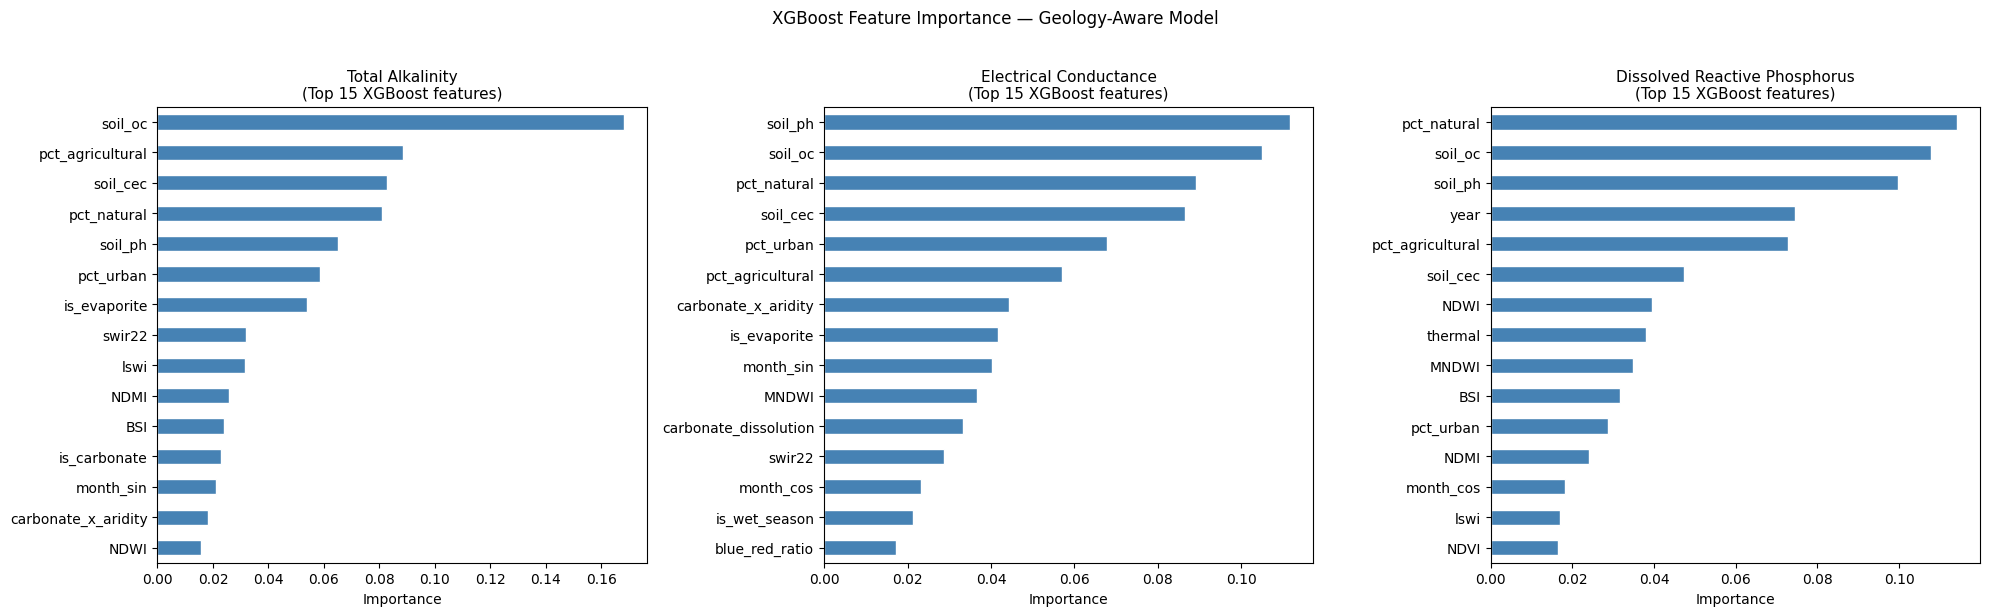

In [38]:
# ── Feature importance (XGBoost component) ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (t_key, t_col) in zip(axes, TARGET_COLS.items()):
    imp_ser = pd.Series(final_models[t_key]['xgb'].feature_importances_, index=FEATURE_COLS)
    top15   = imp_ser.nlargest(15)
    top15[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{t_col}\n(Top 15 XGBoost features)', fontsize=11)
    ax.set_xlabel('Importance')
plt.suptitle('XGBoost Feature Importance — Geology-Aware Model', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

In [39]:
# ── Build validation feature matrix ───────────────────────────────────────────
val_feats   = val[FEATURE_COLS].copy()
val_imputed = imp_final.transform(val_feats)
val_s       = sc_final.transform(val_imputed)   # for Ridge
val_r       = val_imputed                        # for XGBoost

print(f"Validation feature shape : {val_imputed.shape}")
print(f"NaN after imputation     : {np.isnan(val_imputed).sum()}")
print()
print("Validation vs Training feature means:")
for col in ['aridity', 'ppt', 'NDMI', 'tmax', 'soil_ph', 'soil_oc', 'baseflow_index',
            'pct_natural', 'pct_agricultural']:
    tm, vm = train[col].mean(), val[col].mean()
    flag   = " ◄" if abs(vm - tm) / (abs(tm) + 1e-9) > 0.3 else ""
    print(f"  {col:25s}: train={tm:.3f}  val={vm:.3f}{flag}")

Validation feature shape : (200, 53)
NaN after imputation     : 0

Validation vs Training feature means:
  aridity                  : train=13.813  val=6.483 ◄
  ppt                      : train=42.299  val=49.351
  NDMI                     : train=0.021  val=0.074 ◄
  tmax                     : train=26.080  val=24.218
  soil_ph                  : train=6.546  val=6.503
  soil_oc                  : train=17.192  val=24.298 ◄
  baseflow_index           : train=12.044  val=7.549 ◄
  pct_natural              : train=0.130  val=0.072 ◄
  pct_agricultural         : train=0.078  val=0.043 ◄


In [40]:
# ── Predict & save submission ─────────────────────────────────────────────────
predictions = {}
for t_key, t_col in TARGET_COLS.items():
    m = final_models[t_key]
    pred_log = m['w_ridge'] * m['ridge'].predict(val_s) + (1 - m['w_ridge']) * m['xgb'].predict(val_r)
    pred     = np.clip(np.expm1(pred_log), 0, None)
    predictions[t_key] = pred
    print(f"{t_col:35s}: min={pred.min():.1f}  mean={pred.mean():.1f}  median={np.median(pred):.1f}  max={pred.max():.1f}")

print()
print("Reference (20 training sites near Eastern Cape): TA≈87, EC≈296")

submission_df = pd.DataFrame({
    'Latitude':                      submission_tmpl['Latitude'].values,
    'Longitude':                     submission_tmpl['Longitude'].values,
    'Sample Date':                   submission_tmpl['Sample Date'].values,
    'Total Alkalinity':              predictions['TA'],
    'Electrical Conductance':        predictions['EC'],
    'Dissolved Reactive Phosphorus': predictions['DRP'],
})
submission_df.to_csv('submission.csv', index=False)
print("\nsubmission.csv saved.")
submission_df.head()

Total Alkalinity                   : min=37.6  mean=74.1  median=57.6  max=160.4
Electrical Conductance             : min=114.5  mean=351.2  median=362.3  max=692.3
Dissolved Reactive Phosphorus      : min=12.6  mean=21.5  median=21.3  max=36.6

Reference (20 training sites near Eastern Cape): TA≈87, EC≈296

submission.csv saved.


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-32.043333,27.822778,01-09-2014,89.404694,336.498968,25.450215
1,-33.329167,26.077500,16-09-2015,57.637178,542.342607,24.316886
2,-32.991639,27.640028,07-05-2015,48.746655,193.019176,20.586443
3,-34.096389,24.439167,07-02-2012,40.268388,202.793097,15.404730
4,-32.000556,28.581667,01-10-2014,63.970327,198.621193,19.356952


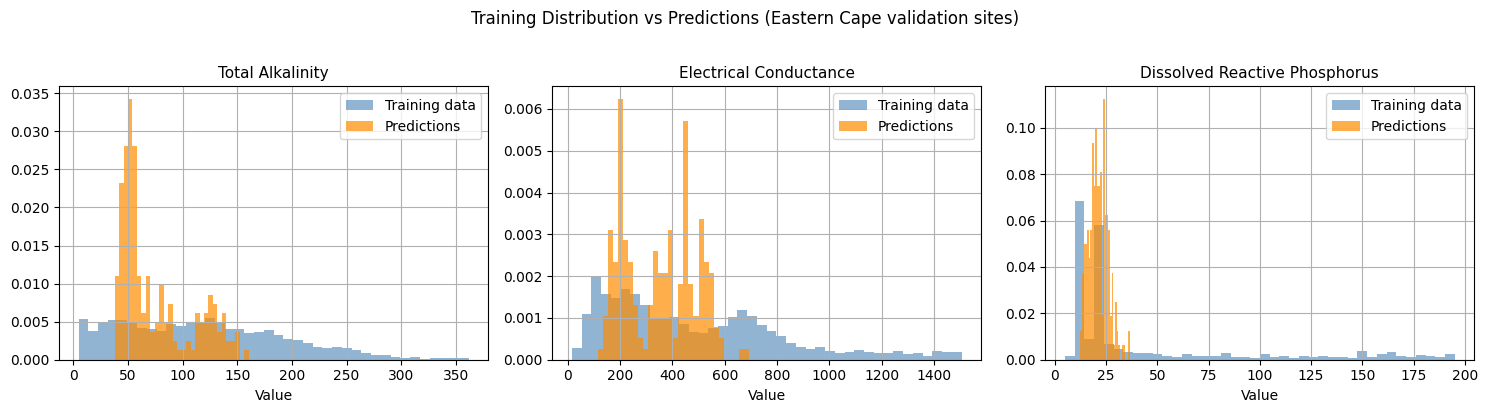

In [41]:
# ── Predicted vs training distribution check ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (t_key, t_col) in zip(axes, TARGET_COLS.items()):
    train[t_col].hist(bins=40, ax=ax, alpha=0.6, label='Training data', color='steelblue', density=True)
    pd.Series(predictions[t_key]).hist(bins=30, ax=ax, alpha=0.7, label='Predictions', color='darkorange', density=True)
    ax.set_title(t_col, fontsize=11)
    ax.legend(); ax.set_xlabel('Value')
plt.suptitle('Training Distribution vs Predictions (Eastern Cape validation sites)', y=1.02)
plt.tight_layout()
plt.savefig('prediction_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## Model Summary

### Design decisions
| Decision | Reason |
|----------|---------|
| No lat/lon or geographic features | Eastern Cape geology ≠ Western Cape at same coordinates → catastrophic bias (ext. R²=−0.452) |
| `is_carbonate`, `is_evaporite`, `carbonate_dissolution` | Direct bedrock geology → primary driver of TA/EC. Previously missing signal. |
| `baseflow_index` | Geological control on streamflow persistence; high in carbonate/fractured rock |
| `soil_ph`, `soil_cec`, `soil_oc` | Soil chemistry proxies; pH corr ~0.7 with stream TA |
| Geology × climate interactions | e.g., carbonate × aridity: carbonate sites concentrate ions in dry months |
| Ridge alpha=500 (TA/EC) | Less extreme regularization than before — geology features provide real between-site signal |
| XGB depth=4 | Allows geology×climate interaction trees (e.g., if carbonate AND high aridity → high EC) |
| 40/60 Ridge:XGB (TA/EC) | More weight to XGB since it better captures nonlinear geology interactions |
| log1p target transform | Right-skewed distributions (TA, EC, DRP all have long right tails) |

### Feature groups (58 total)
| Group | Features | Target |
|-------|----------|--------|
| TerraClimate | pet, ppt, tmax, soil, q, aet, def | TA, EC, DRP |
| Climate ratios | aridity, water_stress, baseflow_index, aet_pet, moisture_surplus | TA, EC |
| Geology | is_carbonate, is_evaporite, carbonate_dissolution, soil_ph, soil_cec, soil_oc | TA, EC, DRP |
| Landsat | NDMI, MNDWI, NDWI, NDVI, BSI, EVI, LSWI, thermal, red_turbidity, … | DRP, temporal |
| Biological | bio_P_uptake, seasonal_drp_pulse, thermal_conc | DRP |
| Interactions | carbonate×aridity, soil_ph×ppt, agri×ppt, … | all |

### External leaderboard
| Submission | External R² |
|------------|------------|
| Benchmark XGB (baseline) | −0.547 |
| Ridge + XGB with geography | −0.452 |
| Ridge + XGB no geography (session 2) | *submitted* |
| **Geology-aware model (this notebook)** | *pending* |
| Best on leaderboard (Rishbha Jain) | 0.203 |
